In [1]:
import pandas as pd
import numpy as np

# Importing sources into datasets
i3e0 = pd.read_csv('/home/jmcrae/Downloads/data/file0.csv')
i3e1 = pd.read_csv('/home/jmcrae/Downloads/data/file1.csv')
i3e2 = pd.read_csv('/home/jmcrae/Downloads/data/file2.csv')
i3e3 = pd.read_csv('/home/jmcrae/Downloads/data/file3.csv')
i3e4 = pd.read_csv('/home/jmcrae/Downloads/data/file4.csv')

i3eDF = pd.concat([i3e0, i3e1, i3e2, i3e3, i3e4])
i3eDF['subject'] = np.nan
i3eDF = i3eDF.rename(columns={'text_combined': 'body'})
i3eDF = i3eDF[['subject', 'body', 'label']]

enronDF = pd.read_csv('/home/jmcrae/repos/info4290_integration/data/orig/enron/spam_ham_dataset.csv')
del enronDF['label']
enronDF = enronDF.rename(columns={'text': 'body', 'label_num': 'label'})
enronDF = enronDF[['subject', 'body', 'label']]

mailDataDF = pd.read_csv('/home/jmcrae/repos/info4290_integration/data/orig/Spam_Mail_Prediction/mail_data.csv')
mailDataDF['Category'] = np.where(mailDataDF['Category'] == "ham", 0, 1)
mailDataDF['subject'] = np.nan
mailDataDF = mailDataDF.rename(columns={'Category': 'label', 'Message': 'body'})
mailDataDF = mailDataDF[['subject', 'body', 'label']]

emailSpamDF = pd.read_csv('/home/jmcrae/repos/info4290_integration/data/orig/UniqueData_email-spam-classification/email_spam.csv')
emailSpamDF['type'] = np.where(emailSpamDF['type'] == "not spam", 0, 1)
emailSpamDF = emailSpamDF.rename(columns={'title': 'subject', 'text': 'body', 'type': 'label'})
emailSpamDF = emailSpamDF[['subject', 'body', 'label']]

In [2]:
i3eDF

,subject,body,label
0,NaN,fark rssfeedsspamassassintaintorg url date 200...,0
1,NaN,alamac thanks painful got contract says 5 busi...,0
2,NaN,daily top 10 tanneryteunion104tnet daily top 1...,1
3,NaN,liza everett linpillardmetpillardde po dh ren ...,1
4,NaN,czanikhotmailcom font face3dverdana size3d3 co...,1
...,...,...,...
5779,NaN,congrats vince beat congrats surprise already ...,0
5780,NaN,jason haar aldsebvqjtrimbleconz andy dills wro...,0
5781,NaN,alexandra qa4wudt5x333hotmailcom find chatting...,1
5782,NaN,potential well head january 2000 darren follow...,0


In [3]:
enronDF

,subject,body,label
0,enron methanol ; meter # : 988291,this is a follow up to the note i gave you on ...,0
1,"hpl nom for january 9 , 2001",( see attached file : hplnol 09 . xls )\r\n- h...,0
2,neon retreat,"ho ho ho , we ' re around to that most wonderf...",0
3,"photoshop , windows , office . cheap . main tr...",abasements darer prudently fortuitous undergon...,1
4,re : indian springs,this deal is to book the teco pvr revenue . it...,0
...,...,...,...
5166,put the 10 on the ft,the transport volumes decreased from 25000 to ...,0
5167,3 / 4 / 2000 and following noms,hpl can ' t take the extra 15 mmcf / d over th...,0
5168,calpine daily gas nomination,">\r\n>\r\njulie , as i mention earlier we hope...",0
5169,industrial worksheets for august 2000 activity,attached are the worksheets for august 2000 ac...,0


In [4]:
mailDataDF

,subject,body,label
0,NaN,"Go until jurong point, crazy.. Available only ...",0
1,NaN,Ok lar... Joking wif u oni...,0
2,NaN,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,NaN,U dun say so early hor... U c already then say...,0
4,NaN,"Nah I don't think he goes to usf, he lives aro...",0
...,...,...,...
5567,NaN,This is the 2nd time we have tried 2 contact u...,1
5568,NaN,Will ü b going to esplanade fr home?,0
5569,NaN,"Pity, * was in mood for that. So...any other s...",0
5570,NaN,The guy did some bitching but I acted like i'd...,0


In [5]:
emailSpamDF

,subject,body,label
0,?? the secrets to SUCCESS,"Hi James,\n\nHave you claim your complimentary...",1
1,?? You Earned 500 GCLoot Points,"\nalt_text\nCongratulations, you just earned\n...",0
2,?? Your GitHub launch code,"Here's your GitHub launch code, @Mortyj420!\n ...",0
3,[The Virtual Reward Center] Re: ** Clarifications,"Hello,\n \nThank you for contacting the Virtua...",0
4,"10-1 MLB Expert Inside, Plus Everything You Ne...","Hey Prachanda Rawal,\n\nToday's newsletter is ...",1
...,...,...,...
79,Your application for the position of Child Pr...,"Dear Maryam, \n\n \n\nI would like to thank yo...",0
80,Your Kilimall Account is Ready - Shopping Now!,"Dear Customer,\n\nWelcome to Kilimall, Thanks ...",0
81,Your Steam account: Access from new web or mob...,"Dear vladis163rus,\nHere is the Steam Guard co...",0
82,Your uploaded document is rejected,View In Browser | Log in\n \n \n\nSkrill logo\...,0


In [6]:
# Merging datasets into one corpus for training
spamCorpus = pd.concat([emailSpamDF,enronDF])
spamCorpus = pd.concat([spamCorpus,i3eDF])
spamCorpus = pd.concat([spamCorpus,mailDataDF])
spamCorpus

,subject,body,label
0,?? the secrets to SUCCESS,"Hi James,\n\nHave you claim your complimentary...",1
1,?? You Earned 500 GCLoot Points,"\nalt_text\nCongratulations, you just earned\n...",0
2,?? Your GitHub launch code,"Here's your GitHub launch code, @Mortyj420!\n ...",0
3,[The Virtual Reward Center] Re: ** Clarifications,"Hello,\n \nThank you for contacting the Virtua...",0
4,"10-1 MLB Expert Inside, Plus Everything You Ne...","Hey Prachanda Rawal,\n\nToday's newsletter is ...",1
...,...,...,...
5567,NaN,This is the 2nd time we have tried 2 contact u...,1
5568,NaN,Will ü b going to esplanade fr home?,0
5569,NaN,"Pity, * was in mood for that. So...any other s...",0
5570,NaN,The guy did some bitching but I acted like i'd...,0


In [7]:
# Importing modules for preprocessing and training
import matplotlib.pyplot as plt
import seaborn as sns

import string
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud
nltk.download('stopwords')

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package stopwords to /home/jmcrae/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


<Axes: xlabel='label', ylabel='count'>

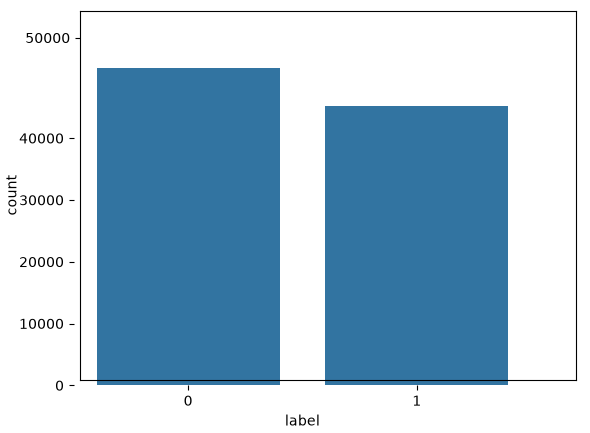

In [8]:
# Visualizing balance of ham and spam
sns.countplot(x='label',data=spamCorpus)

<Axes: xlabel='label', ylabel='count'>

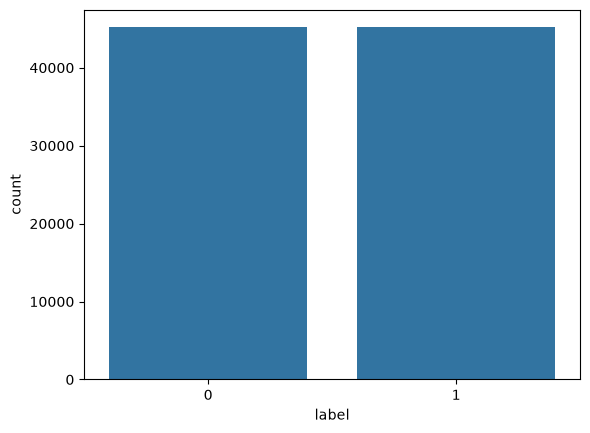

In [9]:
# Balancing dataset to account for slightly higher instance of ham email
ham = spamCorpus[spamCorpus['label'] == 0]
spam = spamCorpus[spamCorpus['label'] == 1]

ham_bal = ham.sample(n=len(spam), random_state=12)

spamCorpus_bal = pd.concat([ham_bal, spam]).reset_index(drop=True)

sns.countplot(x='label', data=spamCorpus_bal)

In [10]:
# Replace NaN subject values with empty string so they can be parsed
spamCorpus_bal = spamCorpus_bal.fillna('')

In [11]:
# Method to remove punctuation
punctuation = string.punctuation
def rm_punctuation(text):
    temp = str.maketrans('', '', punctuation)
    return text.translate(temp)

# Remove punctuation from subject and body
spamCorpus_bal['subject']= spamCorpus_bal['subject'].apply(lambda x: rm_punctuation(x))
spamCorpus_bal['body']= spamCorpus_bal['body'].apply(lambda x: rm_punctuation(x))

In [12]:
# Method to remove stopwords
def rm_stopwords(text):
    stwords = stopwords.words('english')
    indexed_words = []

    for word in str(text).split():
        word = word.lower()
        if word not in stwords:
            indexed_words.append(word)
            
    output = " ".join(indexed_words)
    return output

# Remove stopwords from subject and body
spamCorpus_bal['subject'] = spamCorpus_bal['subject'].apply(lambda text: rm_stopwords(text))
spamCorpus_bal['body'] = spamCorpus_bal['body'].apply(lambda text: rm_stopwords(text))

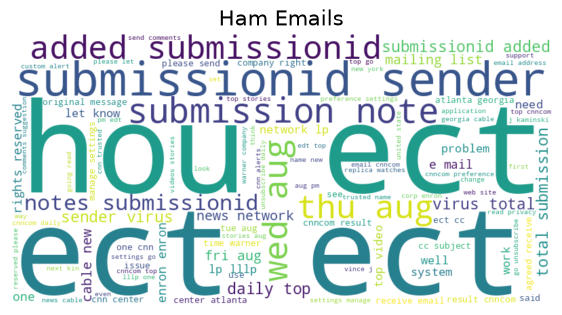

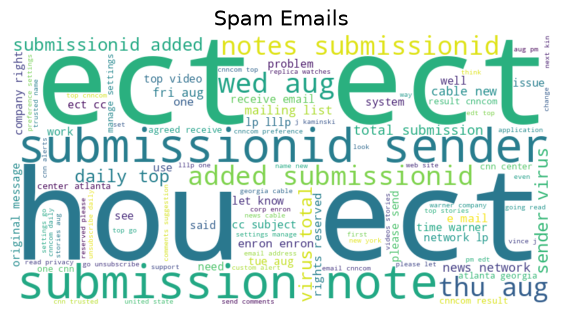

In [13]:
# Generate wordclouds to get general picture of mail contents
def plot_wordcloud(data, label):
    corpus = " ".join(spamCorpus_bal['body'])
    wc = WordCloud(background_color='white', max_words=100, width=800, height=400).generate(corpus)
    plt.figure(figsize=(7, 7))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(f'{label} Emails', fontsize=15)
    plt.axis('off')
    plt.show()

plot_wordcloud(spamCorpus_bal[spamCorpus_bal['label'] == 0], label='Ham')
plot_wordcloud(spamCorpus_bal[spamCorpus_bal['label'] == 1], label='Spam')

In [14]:
# Integrating the subject and body text into one column
# Initially I thought that it would be better to keep them separate but this would make tokenization needlessly complex
spamCorpus_bal['subj_body'] = (spamCorpus_bal['subject'].fillna('') + ' ' + spamCorpus_bal['body'].fillna(''))
spamCorpus_bal

,subject,body,label,subj_body
0,,tomorrow onwards eve 6 3 work,0,tomorrow onwards eve 6 3 work
1,,hello handsome finding job lazy working toward...,0,hello handsome finding job lazy working towar...
2,,dintelmann peter wstjdlwgstoezghdresdnerbankco...,0,dintelmann peter wstjdlwgstoezghdresdnerbankc...
3,,kgrtljpowncecom hello pownce want let know new...,0,kgrtljpowncecom hello pownce want let know ne...
4,,kai ponte xdbperfectreigncom saturday 16 febru...,0,kai ponte xdbperfectreigncom saturday 16 febr...
...,...,...,...,...
90307,,want explicit sex 30 secs ring 02073162414 cos...,1,want explicit sex 30 secs ring 02073162414 co...
90308,,asked 3mobile 0870 chatlines inclu free mins i...,1,asked 3mobile 0870 chatlines inclu free mins ...
90309,,contract mobile 11 mnths latest motorola nokia...,1,contract mobile 11 mnths latest motorola noki...
90310,,reminder o2 get 250 pounds free call credit de...,1,reminder o2 get 250 pounds free call credit d...


In [15]:
# Splitting data into test and training sets
# 20% of the data will be used for testing, 80% for training
train_X, test_X, train_Y, test_Y = train_test_split(
    spamCorpus_bal['subj_body'], spamCorpus_bal['label'], test_size=0.2, random_state=12
)

# Creating tokenizer and reading data
tokenizer = Tokenizer()
tokenizer.fit_on_texts(train_X)

# Tokenize training and test data
train_seq = tokenizer.texts_to_sequences(train_X)
test_seq = tokenizer.texts_to_sequences(test_X)

# Set maximum sequence length to 300 words and pad
max_len = 300
train_seq = pad_sequences(train_seq, maxlen = max_len, padding = 'post', truncating = 'post')
test_seq = pad_sequences(test_seq, maxlen = max_len, padding = 'post', truncating = 'post')

In [16]:
# Model selection
model = tf.keras.models.Sequential([
    tf.keras.layers.Embedding(input_dim=len(tokenizer.word_index) + 1, output_dim=32, input_length=max_len),
    tf.keras.layers.LSTM(16),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Model compilation
model.compile(
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Training model
es = EarlyStopping(patience=3, monitor='val_accuracy', restore_best_weights=True)
lr = ReduceLROnPlateau(patience=2, monitor='val_loss', factor=0.5, verbose=0)

history = model.fit(
    train_seq, train_Y,
    validation_data=(test_seq, test_Y),
    epochs=20,
    batch_size=32,
    callbacks=[lr, es]
)

Epoch 1/20
 188/2258 ━━━━━━━━━━━━━━━━━━━━ 6:45 196ms/step - accuracy: 0.5274 - loss: 0.7478